🌧️# 내일 비가 올지 예측(Rain in Australia)
- 참고 : https://www.kaggle.com/prashant111/extensive-analysis-eda-fe-modelling
- 랜덤 포레스트(Random Forest)

### 📌 전체 흐름 한눈에 보기

```
1) 데이터 읽기        →  CSV 파일을 표(DataFrame)로 불러오기
2) EDA (탐색적 분석)  →  데이터가 어떻게 생겼는지 눈으로 확인
3) 전처리             →  결측치 채우기 / 필요없는 컬럼 삭제 / 글자를 숫자로 변환
4) 데이터 분할        →  학습용(train) 70% : 테스트용(test) 30%
5) 모델 학습 & 평가   →  DT / RF / XGBoost 성능 비교
```


# 관련 라이브러리 import

In [100]:
# 불필요한 경고 출력을 방지
# 코드 실행 중에 나오는 '경고(Warning)' 메시지를 화면에 표시하지 않도록 설정
import warnings
warnings.filterwarnings('ignore')

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split # 데이터를 학습용/테스트용으로 나눠주는 함수

# 주피터 노트북 안에 그래프를 바로 그려주는 설정 (매직 커맨드)
%matplotlib inline

print('라이브러리 import 완료')
print('pandas 버전 :', pd.__version__)

라이브러리 import 완료
pandas 버전 : 3.0.5


# 데이터 준비
- 아래 링크에서 weatherAUS.csv 파일을 다운로드 받기
#### https://www.kaggle.com/jsphyg/weather-dataset-rattle-package



## 데이터 읽기 
 -날씨

In [102]:
# CSV 파일을 읽어서 DataFrame(표) 으로 만들기
df = pd.read_csv('datas_ml/weatherAUS.csv')
# pd.read_csv() : 쉼표(,)로 구분된 텍스트 파일을 읽어서 DataFrame으로 만들어 주는 함수
# df.shape : (행 개수, 열 개수) 를 알려줍니다.
print(df.shape)

(145460, 23)


# EDA 수행

> **EDA란?** 모델을 만들기 전에 "이 데이터가 대체 어떻게 생겼지?" 를 눈으로 확인하는 단계
> 결측치는 얼마나 있는지, 값의 범위는 어떤지, 어떤 컬럼이 정답과 관련이 깊은지 확인 

## 데이터 형상 파악하기

In [103]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [104]:
df.info()
# .info() : 컬럼 이름 / 결측치가 아닌 값의 개수 / 데이터 타입(dtype) 
#  - float64 : 실수(소수점 있는 숫자)
#  - object 또는 str : 문자열 (예: 'Albury', 'Yes', 'No')
#  - Non-Null Count 가 전체 행 수(145460)보다 작으면 → 그만큼 결측치(빈 값)가 있

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [ ]:
df.describe()

# .describe() : 숫자형 컬럼들의 기초 통계량을 요약해서 보여줌 
#  count : 값이 있는 개수     mean : 평균        std : 표준편차(값이 얼마나 퍼져있나)
#  min   : 최솟값            25%/50%/75% : 사분위수(50%가 중앙값)   max : 최댓값

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


## 범주형 데이터 통계량 확인

In [ ]:
cat_columns = df.select_dtypes(exclude=np.number).columns

# select_dtypes() : 원하는 데이터 타입의 컬럼만 골라내는 함수
#  - exclude=np.number → "숫자가 아닌 것만" = 문자열(범주형) 컬럼만 선택

cat_columns

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')

In [ ]:
print(cat_columns)
# 범주형 컬럼에 .describe()를 쓰면 숫자와는 다른 정보가 나옴. 
#  count  : 값이 있는 개수
#  unique : 서로 다른 값이 몇 종류인지 (예: Location은 49개 도시)
#  top    : 가장 많이 나온 값 (= 최빈값)
#  freq   : top 값이 몇 번 나왔는지
df[cat_columns].describe()

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,145460,145460,135134,134894,141232,142199,142193
unique,3436,49,16,16,16,2,2
top,2013-03-01,Canberra,W,N,SE,No,No
freq,49,3436,9915,11758,10838,110319,110316


## target(y) 데이터 확인

RainTomorrow
0    110316
1     31877
Name: count, dtype: int64

RainTomorrow
0    0.775819
1    0.224181
Name: proportion, dtype: float64


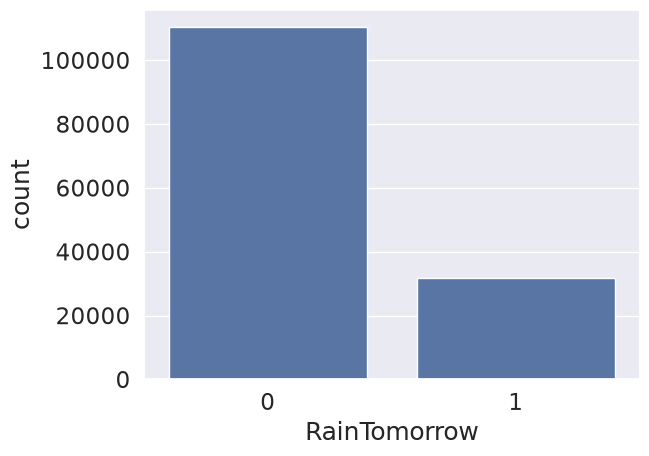

In [46]:
# 정답(target) = 'RainTomorrow' (내일 비가 오는가?)
# countplot : 각 값이 몇 개씩 있는지 막대그래프로 그려줍니다.
sns.countplot(x="RainTomorrow", data=df)

#  No(비 안 옴)가 Yes(비 옴)보다 압도적으로 많음 
#  '불균형 데이터(imbalanced data)' 
#  → 무조건 "내일 비 안 와!" 라고만 찍어도 정확도가 78%쯤
#  → 나중에 정확도(accuracy)만 보면 안 되고, 정밀도/재현율/F1도 같이 봐야 함 **

print(df['RainTomorrow'].value_counts())
print()
print(df['RainTomorrow'].value_counts(normalize=True))  # 비율(%)로 보기

## 상관 분석(Correlation Analysis) 수행해보기

### 수치형 데이터 확인

In [ ]:
# include=np.number → "숫자인 것만" = 수치형 컬럼만 선택
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')

In [47]:
# 수치형 컬럼만 뽑아서 temp_df 라는 새 표를 작성 
#  .copy() 를 붙이는 이유 : 원본 df를 건드리지 않고 '복사본'을 따로 만들기 위해서
#  (copy를 안 하면 나중에 값을 바꿀 때 경고가 뜨거나 원본이 같이 바뀔 수 있음)
temp_df = df[num_cols]
temp_df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8
1,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3
2,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2
3,9.2,28.0,0.0,4.8,8.4,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5
4,17.5,32.3,1.0,4.8,8.4,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7


### 범주형 데이터를 수치형으로 변환
 - 상관계수는 숫자끼리만 계산할 수 있음
- RainToday, RainTomorrow 컬럼의 데이터를 수치형으로 변환
- 변환하여 수치형 데이터 프레임에 추가

In [ ]:
# .map({...}) : 값을 다른 값으로 1:1 치환하는 함수
#   'No' → 0,  'Yes' → 1 (딕셔너리에 없는 값이나 결측치는 NaN)
temp_df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1}) #.astype(dtype='int')
temp_df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1}) #.astype(dtype='int')

In [70]:
temp_df.shape
# 컬럼 2개가 추가되었는지 확인 (16개 → 18개)

(142193, 16)

In [71]:
temp_df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8
1,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3
2,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2
3,9.2,28.0,0.0,4.8,8.4,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5
4,17.5,32.3,1.0,4.8,8.4,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7


### 상관관계 계수 확인
- **상관계수(correlation)** 는 -1 ~ 1 사이의 값.
  - `1`에 가까울수록 : 한쪽이 커지면 다른 쪽도 커짐 (양의 상관)
  - `-1`에 가까울수록 : 한쪽이 커지면 다른 쪽은 작아짐 (음의 상관)
  - `0`에 가까울수록 : 별 관계 없음
- 맨 아래 `RainTomorrow` 줄을 보면 **어떤 변수가 '내일 비'와 관련이 깊은지** 확인 가능 

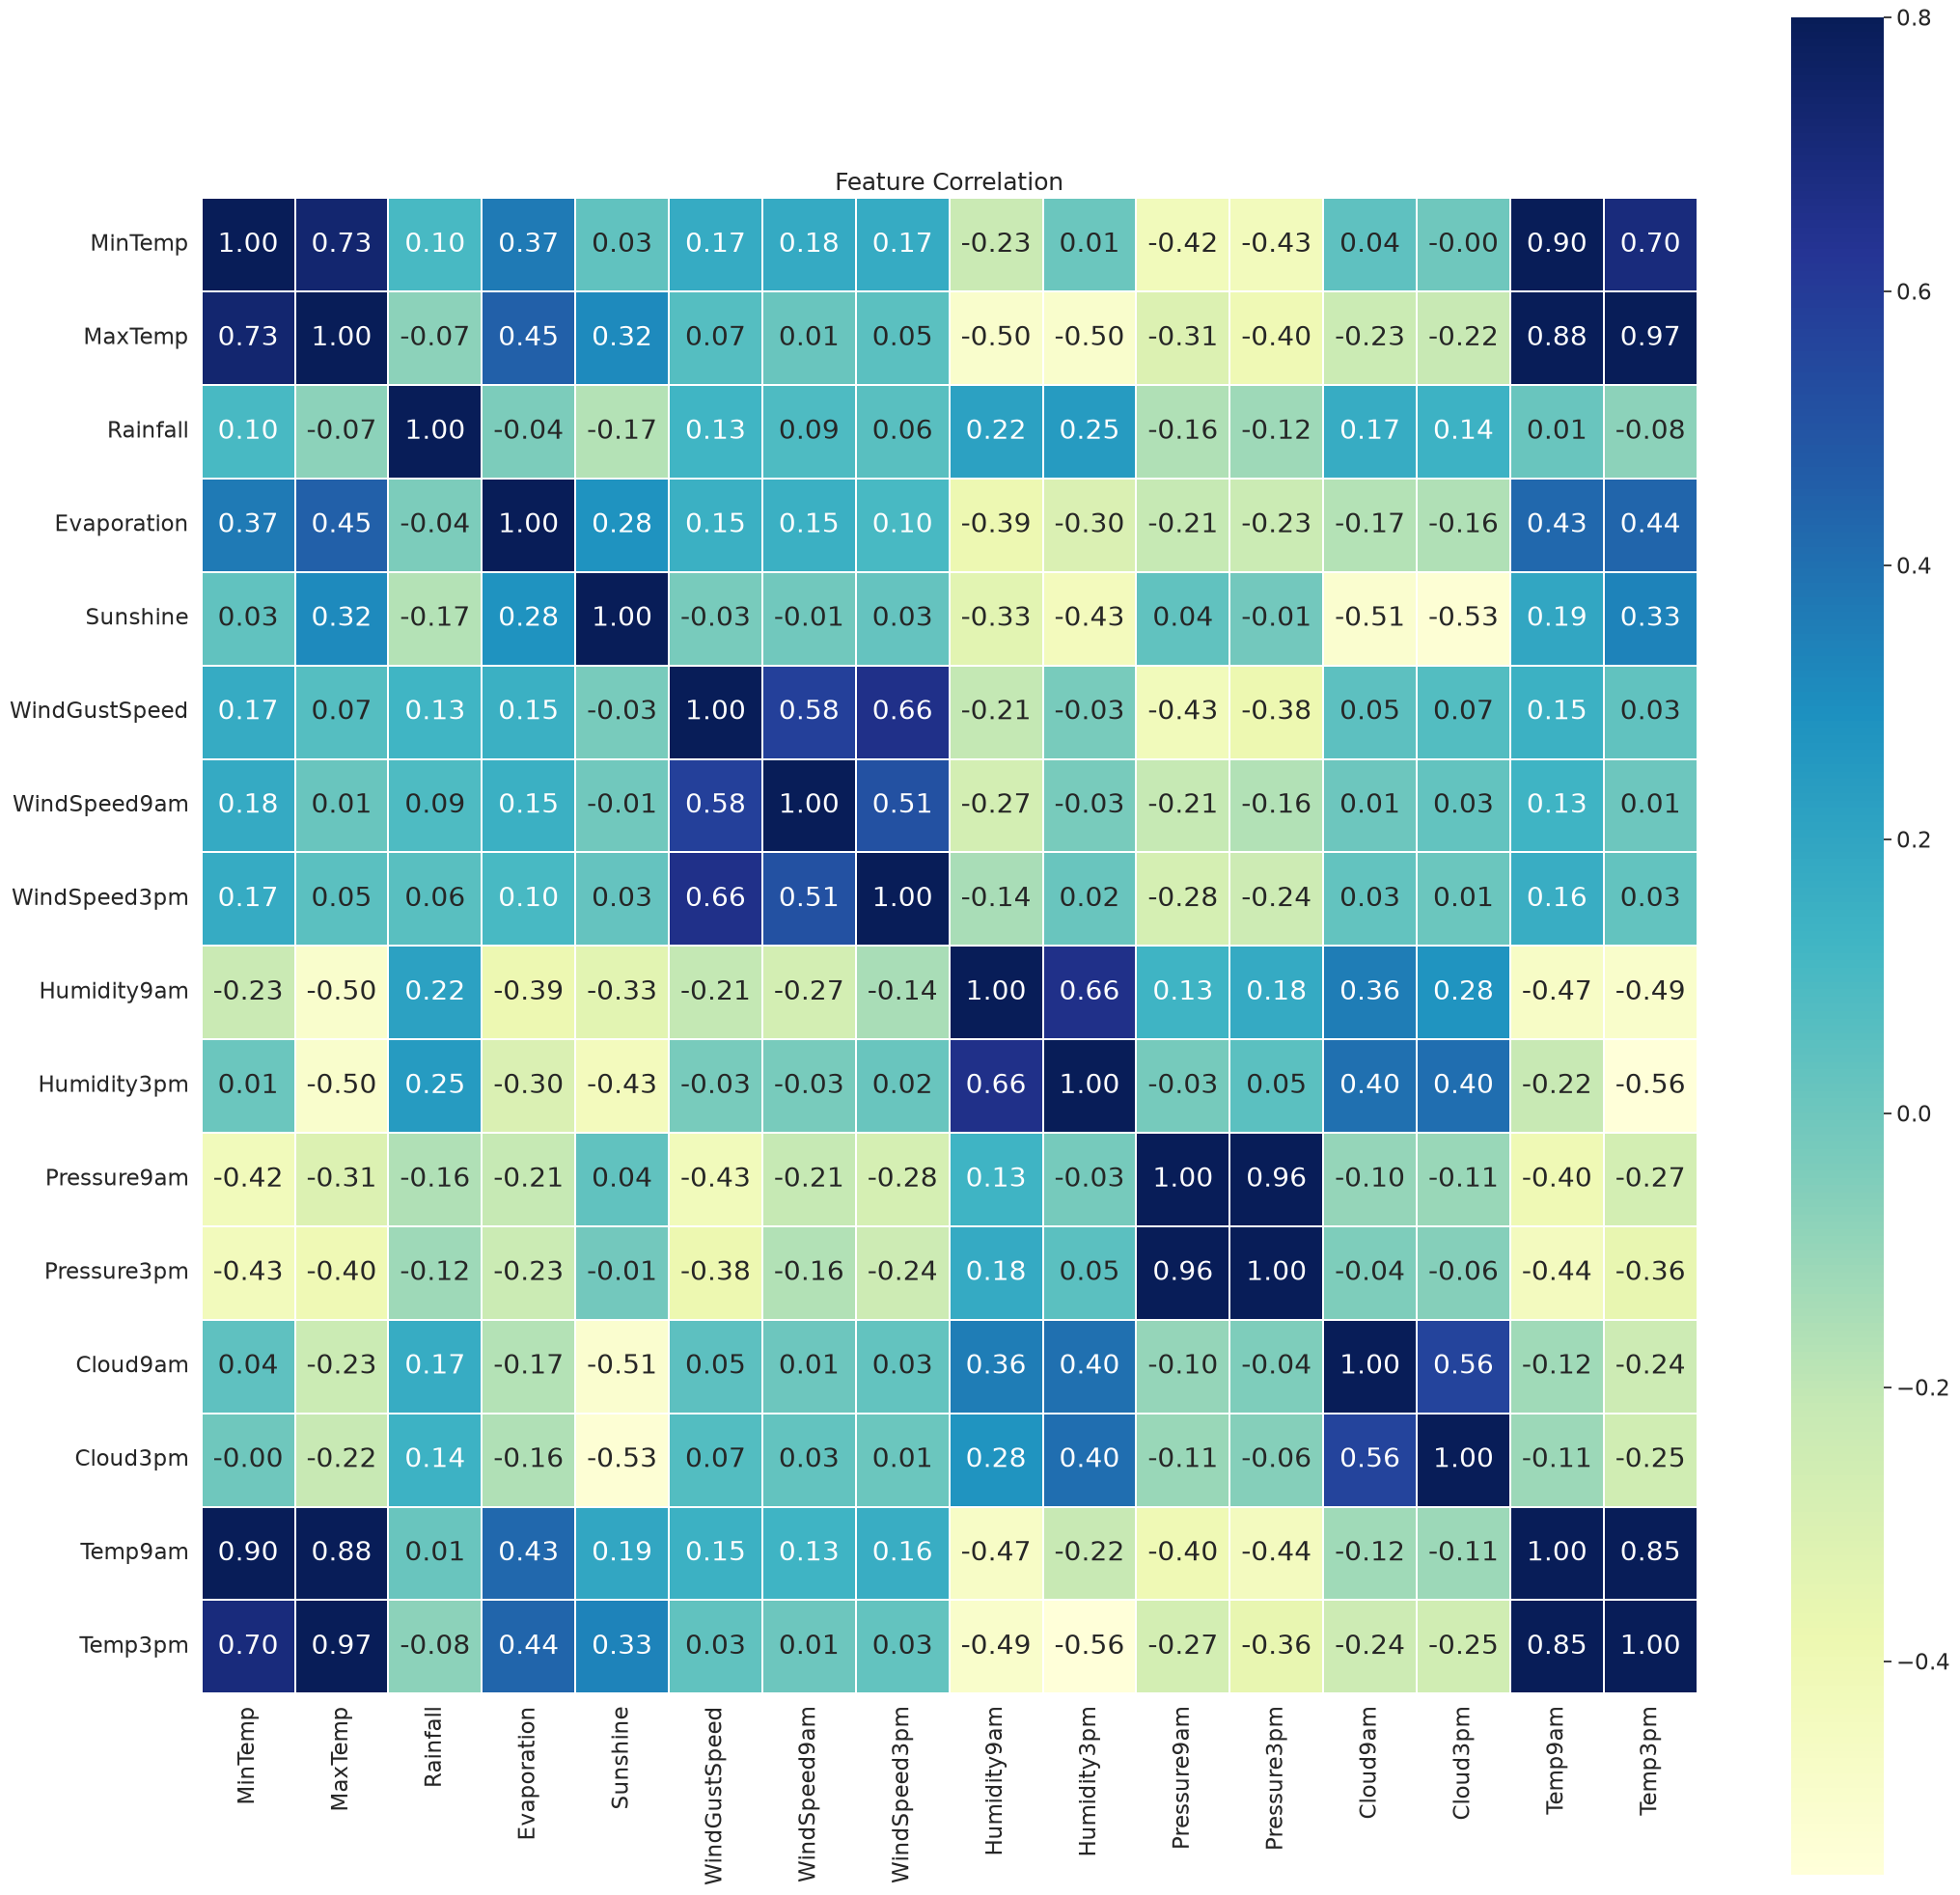

In [66]:
# .corr() : 모든 숫자 컬럼끼리의 상관계수를 표(행렬)로 계산

corr = temp_df.corr()

plt.figure(figsize=(25, 25)); #그래프 크기 (가로, 세로 ) 단위 = 인치 
sns.set(font_scale=1.5); # plot의 글자크기 설정

# heatmap : 숫자 표를 '색깔 지도'로 그려주는 그래프. 값이 클수록 진한 색.
sns.heatmap(corr,
            vmax=0.8,
            #vmin=-1,
            linewidths=0.01,   #칸 사이 경계선 두께
            square=True,
            annot=True,
            fmt = '.2f', # annot의 출력 소숫점 자리 지정
            annot_kws={"size": 20},
            cmap='YlGnBu');
plt.title('Feature Correlation');

# 결측치 처리
## (null값) 확인하기

In [65]:
df.isnull().mean().sort_values()

# .isnull()        : 각 칸이 비었으면 True, 값이 있으면 False 인 표를 만듦
# .mean()          : True를 1, False를 0으로 보고 평균 → 즉 '결측치 비율'
# .sort_values()   : 작은 값부터 정렬
#  → 결과가 0.0 이면 결측치 없음, 0.48 이면 48%가 비어있다는 뜻입니다.

MinTemp           0.0
MaxTemp           0.0
Rainfall          0.0
Evaporation       0.0
Sunshine          0.0
                 ... 
WindDir3pm_SSW    0.0
WindDir3pm_SW     0.0
WindDir3pm_W      0.0
WindDir3pm_WNW    0.0
WindDir3pm_WSW    0.0
Length: 115, dtype: float64

## categorical column 확인하기

In [62]:
cat_cols = df.select_dtypes(exclude=np.number).columns
print(cat_columns)

# 범주형(문자열) 컬럼 목록

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


## numerical column 확인하기

In [61]:
num_cols = df.select_dtypes(include=np.number).columns
print(num_cols)

# 수치형(숫자) 컬럼 목록

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='str')


# 결측치 개수 확인하기

In [60]:
df[cat_cols].isnull().mean().sort_values()

# 범주형 컬럼의 결측치 비율

Location_Adelaide         0.0
Location_Albany           0.0
Location_Albury           0.0
Location_AliceSprings     0.0
Location_BadgerysCreek    0.0
                         ... 
WindDir3pm_SSW            0.0
WindDir3pm_SW             0.0
WindDir3pm_W              0.0
WindDir3pm_WNW            0.0
WindDir3pm_WSW            0.0
Length: 97, dtype: float64

In [58]:
df[num_cols].isnull().mean().sort_values()

#수치형 컬럼의 결측치 비율 
# > sunshine 48% 

MinTemp          0.0
MaxTemp          0.0
Rainfall         0.0
Evaporation      0.0
Sunshine         0.0
WindGustSpeed    0.0
WindSpeed9am     0.0
WindSpeed3pm     0.0
Humidity9am      0.0
Humidity3pm      0.0
Pressure9am      0.0
Pressure3pm      0.0
Cloud9am         0.0
Cloud3pm         0.0
Temp9am          0.0
Temp3pm          0.0
RainToday        0.0
RainTomorrow     0.0
dtype: float64

## 결측치 채우기
### 수치형 컬럼 결측처리
- numerical value를 가진 column은 중위값(meidan)으로 채우기
- 왜 평균(mean)이 아니라 중위값일까요?
  → 아주 큰 값(폭우 등 이상치)이 하나 있으면 평균이 확 끌려가지만, 중위값은 흔들리지 않기 때문입니다.

In [ ]:
#df['Sunshine'].fillna(df['Sunshine'].median())
# pandas에서 fillna()는 '채운 결과를 새로 돌려주는' 함수 -> 아래처럼 결과를 다시 대입(=)하지 않으면 원본 df는 그대로
# df['Sunshine'].fillna(df['Sunshine'].median())        ← ❌ 이렇게만 쓰면 반영 안 됨

df['Sunshine'] = df['Sunshine'].fillna(df['Sunshine'].median())

In [72]:
# 나머지 수치형 컬럼도 반복문(for)으로 한번에 처리

for col in num_cols:                    #수치형 컬럼을 하나씩 꺼내서 
    if df[col].isnull().mean() > 0:     #결측치가 조금이라도 있으면
        col_median = df[col].median()   # 그컬럼의 중위값을 구하고 
        df[col] = df[col].fillna(col_median)  # 빈칸을 중위값으로 채움 


df[num_cols].isnull().mean().sort_values()

MinTemp          0.0
MaxTemp          0.0
Rainfall         0.0
Evaporation      0.0
Sunshine         0.0
WindGustSpeed    0.0
WindSpeed9am     0.0
WindSpeed3pm     0.0
Humidity9am      0.0
Humidity3pm      0.0
Pressure9am      0.0
Pressure3pm      0.0
Cloud9am         0.0
Cloud3pm         0.0
Temp9am          0.0
Temp3pm          0.0
RainToday        0.0
RainTomorrow     0.0
dtype: float64

### 범주형 컬럼 결측처리 
- 문자 컬럼은 **최빈값(mode, 가장 많이 나온 값)** 으로 채우기 
- 단, `RainTomorrow`는 **우리가 맞혀야 할 정답**이므로 임의로 채우면 안 됨 (뒤에서 삭제 처리)
- null이 있는 범주형 컬럼 확인

In [ ]:
# null이 있는 범주형 컬럼과 그 비율 출력 

for col in cat_cols:
    if df[col].isnull().mean() > 0:
        print(col, (df[col].isnull().mean()))

WindGustDir 0.0709885879279527
WindDir9am 0.07263852605527293
WindDir3pm 0.02906641000962464
RainToday 0.022418534304963565
RainTomorrow 0.02245978275814657


In [ ]:
# .mode() 는 최빈값을 'Series(목록)' 형태로 반환 
# 최빈값이 여러개 일 수 있기 때문에 목록으로 반환
# 맨 앞 값 한개를 쓰려면 [0]을 꼭 붙여야함 ! 

# df['WindGustDir'].mode()
df['WindGustDir'].mode()[0]

'W'

In [ ]:
# 방법1 컬럼을 하나씩 직접 지정해서 최빈값으로 채우기
# categorical value를 가진 column은 최빈값(mode)으로 결측치 채우기
# RainTomorrow 는 target 이기 때문에 결측치 처리하지 않음.(일반적인 선택)
df['WindGustDir'] = df['WindGustDir'].fillna(df['WindGustDir'].mode()[0])
df['WindDir9am'] = df['WindDir9am'].fillna(df['WindDir9am'].mode()[0])
df['WindDir3pm'] = df['WindDir3pm'].fillna(df['WindDir3pm'].mode()[0])
df['RainToday'] = df['RainToday'].fillna(df['RainToday'].mode()[0])

In [85]:
# cat_cols= list(cat_cols)
# cat_cols

In [86]:
# cat_cols.remove('RainTomorrow')
# cat_cols

In [87]:
# 방법2
# for col in cat_cols:
#     if df[col].isnull().mean() > 0:
#         df[col] = df[col].fillna(df[col].mode()[0])

In [74]:
df.info()

<class 'pandas.DataFrame'>
Index: 142193 entries, 0 to 145458
Columns: 115 entries, MinTemp to WindDir3pm_WSW
dtypes: bool(97), float64(16), int64(2)
memory usage: 33.8 MB


In [75]:
df.isnull().sum()

MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation       0
Sunshine          0
                 ..
WindDir3pm_SSW    0
WindDir3pm_SW     0
WindDir3pm_W      0
WindDir3pm_WNW    0
WindDir3pm_WSW    0
Length: 115, dtype: int64

## 필요 없는 컬럼 삭제 

In [ ]:
df = df.drop(['Date'], axis=1)

# .drop(['컬럼명'], axis=1) : 컬럼(세로줄)을 삭제
#   axis=0 → 행(가로줄) 삭제 / axis=1 → 열(세로줄) 삭제  ※ 헷갈리기 쉬우니 꼭 기억!


In [34]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [35]:
df.isnull().mean().sort_values()

Location         0.00000
MinTemp          0.00000
MaxTemp          0.00000
Rainfall         0.00000
Evaporation      0.00000
Sunshine         0.00000
WindGustDir      0.00000
WindGustSpeed    0.00000
WindDir9am       0.00000
WindDir3pm       0.00000
WindSpeed9am     0.00000
WindSpeed3pm     0.00000
Humidity9am      0.00000
Humidity3pm      0.00000
Pressure9am      0.00000
Pressure3pm      0.00000
Cloud9am         0.00000
Cloud3pm         0.00000
Temp9am          0.00000
Temp3pm          0.00000
RainToday        0.00000
RainTomorrow     0.02246
dtype: float64

## target의 null 값처리
- RainTomorrow는 target이기 때문에 nan은 drop으로 처리
- RainTomorrow 예측 값이므로 null 값 삭제함

In [ ]:
df.shape

# 삭제 전 크기

(145460, 22)

In [79]:
df.isnull().sum()
# 삭제 전, 남아있는 결측치 확인 (RainTomorrow만 남아있어야 함)

MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation       0
Sunshine          0
                 ..
WindDir3pm_SSW    0
WindDir3pm_SW     0
WindDir3pm_W      0
WindDir3pm_WNW    0
WindDir3pm_WSW    0
Length: 115, dtype: int64

In [77]:
# .dropna(subset=['컬럼']) : 지정한 컬럼이 비어있는 '행'만 삭제
df = df.dropna(subset=['RainTomorrow'])
df.info()

<class 'pandas.DataFrame'>
Index: 142193 entries, 0 to 145458
Columns: 115 entries, MinTemp to WindDir3pm_WSW
dtypes: bool(97), float64(16), int64(2)
memory usage: 33.8 MB


In [78]:
# 삭제 후 크기 : 145460행 → 142193행 (약 3,267개 행이 삭제됨)
print('삭제 후 :', df.shape)

삭제 후 : (142193, 115)


In [39]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


# Yes/No 값에 대한 변환

In [ ]:
# 순서/크기 의미가 없는 2개짜리 값(Yes/No)은 0과 1로 바꿔주면 충분

df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# dtype이 int(정수)로 바뀐 것을 확인
print(df['RainToday'].dtype, df['RainTomorrow'].dtype)

int64 int64


## categorical value에 one-hot encoding 적용하기

In [41]:
cat_cols

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')

In [ ]:
df = pd.get_dummies(df, columns = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'])

# pd.get_dummies() : 원-핫 인코딩을 자동으로 해주는 함수
#   columns=[...] 에 적은 컬럼들이 여러 개의 0/1 컬럼으로 쪼개짐 

In [43]:
df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,22.0,...,False,False,False,False,False,False,False,False,True,False
1,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,25.0,...,False,False,False,False,False,False,False,False,False,True
2,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,30.0,...,False,False,False,False,False,False,False,False,False,True
3,9.2,28.0,0.0,4.8,8.4,24.0,11.0,9.0,45.0,16.0,...,False,False,False,False,False,False,False,False,False,False
4,17.5,32.3,1.0,4.8,8.4,41.0,7.0,20.0,82.0,33.0,...,False,True,False,False,False,False,False,False,False,False


In [ ]:
df.shape

# 22개 컬럼 → 115개 컬럼으로 증가 (원-핫 인코딩 때문)

(142193, 115)

# ML을 위한 학습, 테스트 데이터 준비

In [80]:
# [문제 → 정답] 특징 변수와 타겟 변수 분할하기

X = df.drop('RainTomorrow', axis=1)   # 정답 컬럼만 빼고 나머지 전부 → 문제지
y = df['RainTomorrow']                # 정답 컬럼 하나만 → 정답지

print('X shape :', X.shape)   # (142193, 114)
print('y shape :', y.shape)   # (142193,)

X shape : (142193, 114)
y shape : (142193,)


In [81]:
X.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,22.0,...,False,False,False,False,False,False,False,False,True,False
1,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,25.0,...,False,False,False,False,False,False,False,False,False,True
2,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,30.0,...,False,False,False,False,False,False,False,False,False,True
3,9.2,28.0,0.0,4.8,8.4,24.0,11.0,9.0,45.0,16.0,...,False,False,False,False,False,False,False,False,False,False
4,17.5,32.3,1.0,4.8,8.4,41.0,7.0,20.0,82.0,33.0,...,False,True,False,False,False,False,False,False,False,False


In [82]:
y[:5]

0    0
1    0
2    0
3    0
4    0
Name: RainTomorrow, dtype: int64

In [ ]:
# 정답의 분포 확인 : 0(비 안 옴) 약 11만개 vs 1(비 옴) 약 3만개 → 불균형
y.value_counts()

RainTomorrow
0    110316
1     31877
Name: count, dtype: int64

In [84]:
# [문제]  학습, 테스트 데이터 분할 하기
#  - 학습 : 테스트 = 7 : 3  → test_size=0.3
#  - 불균형 데이터이므로 stratify=y 로 설정
#    (stratify : 학습/테스트 양쪽에 0과 1의 비율을 원본과 똑같이 맞춰서 나눠줌)
#  - 재현을 위해 seed(random_state) 값은 2026으로 설정
#    (같은 seed를 쓰면 몇 번을 실행해도 똑같이 나뉘어서 결과 비교가 가능해집니다)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=2026
)

In [85]:
# 나뉜 결과 확인
#  X_train (99535, 114) : 공부용 문제지 70%
#  X_test  (42658, 114) : 시험용 문제지 30%
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((99535, 114), (42658, 114), (99535,), (42658,))

# ML 모델 학습

## 결정 트리(Decision Tree)로 내일 비가 올지 안올지 예측해보기

In [86]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

#  [문제] 결정 트리 모델 학습 및 예측 수행

# 1) 모델 만들기 (아직 아무것도 모르는 빈 모델)
#    random_state : 트리를 만들 때 무작위성이 들어가므로 결과 고정을 위해 지정
dt_clf = DecisionTreeClassifier(random_state=2026)

# 2) 학습시키기 → .fit(문제지, 정답지)
dt_clf.fit(X_train, y_train)

# 3) 예측하기 → .predict(처음 보는 문제지)  → 0 또는 1 을 돌려줍니다.
y_pred = dt_clf.predict(X_test)

print('학습 & 예측 완료!')

학습 & 예측 완료!


In [87]:
# 예측 결과 : 0 = 내일 비 안 옴, 1 = 내일 비 옴
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(42658,))

In [88]:
# [문제] 결정 트리 정확도 출력
# accuracy_score(실제 정답, 모델의 예측) → 전체 중 몇 %를 맞혔는지
score = accuracy_score(y_test, y_pred)
print('결정 트리(Decision Tree) Accuracy :', score)

결정 트리(Decision Tree) Accuracy : 0.788363261287449


### [문제] 정확도, 정밀도, 재현율, f1-스코아를 값을 확인해 보세요.

| 지표 | 의미 | 쉬운 설명 |
|---|---|---|
| **Accuracy (정확도)** | 전체 중 맞힌 비율 | 그냥 몇 개 맞혔나 |
| **Precision (정밀도)** | "비 온다"고 예측한 것 중 진짜 온 비율 | 우산 챙기라고 했는데 헛수고한 비율이 낮은가 |
| **Recall (재현율)** | 실제로 비 온 날 중 맞힌 비율 | 진짜 비 오는 날을 놓치지 않았나 |
| **F1-score** | 정밀도와 재현율의 조화평균 | 둘의 균형 점수 |

> 불균형 데이터에서는 **정확도만 보면 속습니다.** 반드시 1(비 옴) 클래스의 recall을 확인하세요.

In [89]:
from sklearn.metrics import classification_report
# [문제] classification_report() 결과 출력

# print()로 감싸야 표 모양이 예쁘게 나옴(그냥 쓰면 \n이 그대로 보임)
print(classification_report(y_test, y_pred))

#  - 0 / 1  : 클래스별 성능 (0=비 안 옴, 1=비 옴)
#  - support: 실제 그 클래스의 개수


              precision    recall  f1-score   support

           0       0.87      0.86      0.86     33095
           1       0.53      0.54      0.53      9563

    accuracy                           0.79     42658
   macro avg       0.70      0.70      0.70     42658
weighted avg       0.79      0.79      0.79     42658



In [90]:
# [문제] roc_auc_score 출력, 소숫점 첫째자리까지만 출력
from sklearn.metrics import roc_auc_score

# ROC-AUC : 0.5면 찍는 수준, 1.0이면 완벽. 불균형 데이터 평가에 유용한 지표입니다.
# round(값, 자릿수) : 반올림 함수
print(round(roc_auc_score(y_test, y_pred), 1))


0.7


## 랜덤 포레스트(Random Forest)로  
- 참고 : https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- DT default = 100개를 만들어서 학습을 시킴

In [91]:
from sklearn.ensemble import RandomForestClassifier
# [문제] RandomForestClassifier 분류 모델 학습 및 예측 수행
#   n_estimators=100 : 만들 트리의 개수 (기본값이라 안 써도 되지만 명시했습니다)
#   n_jobs=-1        : CPU 코어를 전부 사용해서 빠르게 학습 (없으면 1개만 사용)
#   ※ 트리를 100개 만들기 때문에 실행에 30초~1분 정도 걸릴 수 있습니다. 기다려 주세요!
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2026, n_jobs=-1)

rf_clf.fit(X_train, y_train)      # 학습
y_pred = rf_clf.predict(X_test)   # 예측

print('학습 & 예측 완료!')

학습 & 예측 완료!


In [92]:
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(42658,))

In [93]:
# 정확도 평가
score = accuracy_score(y_test, y_pred)
print('랜덤 포레스트(Random Forest) Accuracy :', score)


랜덤 포레스트(Random Forest) Accuracy : 0.8541891321674715


In [94]:
from sklearn.metrics import classification_report
# classification_report() 결과 출력
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91     33095
           1       0.77      0.49      0.60      9563

    accuracy                           0.85     42658
   macro avg       0.82      0.73      0.76     42658
weighted avg       0.85      0.85      0.84     42658



In [95]:
# [문제] roc_auc_score 출력, 소숫점 둘째자리까지만 출력
from sklearn.metrics import roc_auc_score

print(round(roc_auc_score(y_test, y_pred), 2))

0.73


# XGBoost 분류기

In [96]:
from xgboost import XGBClassifier
# [문제] xgboost 학습 수행 및 예측
#   n_estimators : 만들 트리 개수
#   learning_rate: 학습 속도(보폭). 작을수록 천천히 꼼꼼하게 학습합니다.
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=2026)

xgb_clf.fit(X_train, y_train)      # 학습
y_pred = xgb_clf.predict(X_test)   # 예측

# 정확도 확인
score = accuracy_score(y_test, y_pred)
print('XGBoost Accuracy :', score)

XGBoost Accuracy : 0.8564630315532843


In [97]:
from sklearn.metrics import classification_report
# [문제] classification_report() 결과 출력
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91     33095
           1       0.76      0.53      0.62      9563

    accuracy                           0.86     42658
   macro avg       0.82      0.74      0.77     42658
weighted avg       0.85      0.86      0.85     42658



In [98]:
# [문제] roc_auc_score 출력, 소숫점 둘째자리까지만 출력
from sklearn.metrics import roc_auc_score

print(round(roc_auc_score(y_test, y_pred), 2))

0.74


In [99]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'Decision Tree': dt_clf,
    'Random Forest': rf_clf,
    'XGBoost': xgb_clf,
}

rows = []
for name, model in models.items():
    pred = model.predict(X_test)
    rows.append({
        '모델': name,
        'Accuracy':  round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),  # 1(비 옴) 기준
        'Recall':    round(recall_score(y_test, pred), 4),
        'F1':        round(f1_score(y_test, pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, pred), 4),
    })

result_df = pd.DataFrame(rows).set_index('모델')
result_df

# 세 모델의 성능을 비교

,Accuracy,Precision,Recall,F1,ROC-AUC
모델,,,,,
Decision Tree,0.7884,0.5275,0.5360,0.5317,0.6987
Random Forest,0.8542,0.7739,0.4939,0.6030,0.7261
XGBoost,0.8565,0.7596,0.5263,0.6218,0.7391
